# Chapter 18. 한국어 BERT Auxiliary Loss — KLUE-YNAT 합성 multi-label + 활성 라벨 개수 보조 회귀 (Phase 2 클라이맥스)

**목표**: Ch 17의 한국어 multi-label 셋업을 *메인 task* 로 그대로 두고, **활성 라벨 *개수* 회귀 보조 헤드** 를 추가합니다. 손실은 가중합:

$$L = L_\text{main}(\text{카테고리 BCE per-label}) + \lambda \cdot L_\text{aux}(\text{활성 개수 MSE})$$

Ch 14(영어 auxiliary, 별점 회귀 보조)의 한국어 버전입니다. 보조 task만 *별점* → *활성 라벨 개수* (몇 개 카테고리가 동시에 등장하는가) 로 달라집니다. 모델 본체·토크나이저·hyperparams 는 Ch 17 과 *완전히 동일*.

핵심 질문은 Ch 14 와 같습니다 — *"보조 task가 메인 task의 정확도를 끌어올리는가?"* 같은 KLUE-BERT 본체를 두 task가 공유 학습하면서, "이 결합 헤드라인이 몇 개 주제를 다루는가" 라는 *밀도 있는 보조 신호* 가 multi-label 카테고리 예측 표현에 도움이 되는지 직접 측정합니다.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 22분 (보조 ON 학습 약 10분 + λ=0 baseline 학습 약 10분 + 평가/시각화)

---

## 학습 흐름

1. 🚀 **실습**: Ch 17 의 KLUE-YNAT 합성 multi-label 데이터에 *활성 라벨 개수* 보조 라벨(`n_active`, 1 또는 2 — 두 헤드라인 결합 시 같은 카테고리면 1) 을 추가. `AutoModel` 위에 메인 헤드 `Linear(H, 7)` 와 보조 헤드 `Linear(H, 1)` 를 직접 attach, `Trainer.compute_loss` 오버라이드.
2. 🔬 **해부**: 메인 metric (micro/macro F1, hamming, AUC) + 보조 metric (RMSE, Pearson r) 동시 측정.
3. 🛠️ **클라이맥스**: 같은 노트북 안에서 **λ=0 baseline** (= Ch 17 재현) 을 학습한 뒤 λ=0.1 결과와 비교 — *보조 loss 가 메인 task 에 도움이 됐는가?* 카테고리별 F1 차이로 시각화.

---

> 📒 **사전 학습 자료**: Ch 14 (영어 auxiliary, 별점 회귀 보조), Ch 17 (한국어 multi-label, KLUE-YNAT 합성). 이번 챕터는 두 챕터의 *결합* — Ch 17 의 한국어 셋업 + Ch 14 의 multi-task 학습 패턴.

> ⚠️ **이번 챕터의 새로운 점**: 보조 라벨이 *데이터에 외부 신호로 있던* (Ch 14 의 별점) 게 아니라 *합성 과정에서 자연스럽게 얻어지는* (`n_active`) 메타데이터. 합성 multi-label 의 *구조적 정보* 를 그대로 보조로 활용하는 패턴.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 14 | DistilBERT + 보조 헤드 | WordPiece (영어) | Yelp + 항목 + 별점 | 메인(5) + 보조(1) | 메인 sigmoid + 보조 없음 | `BCE per-label + λ·MSE` |
| 16 | klue/bert-base | WordPiece (한국어) | KLUE-YNAT (뉴스 7분류) | `Linear(H, 7)` | softmax | `CrossEntropyLoss` |
| 17 | klue/bert-base | 같음 | KLUE-YNAT 합성 multi-label | `Linear(H, 7)` | sigmoid (per-label) | `BCEWithLogitsLoss` (per-label) |
| **18 ← 여기** | klue/bert-base + **보조 헤드** | 같음 | KLUE-YNAT 합성 multi-label + **활성 개수** | **메인(7) + 보조(1)** | 메인 sigmoid + 보조 없음 | **`BCE per-label + λ·MSE`** |
| 19 (다음 Phase 3) | (없음) — 토크나이저 학습 | **직접 학습한 워드레벨** | (코퍼스) | — | — | — |

전체 20챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

## 🔄 변경점 (Diff from Ch 17)

| 축 | Ch 17 (한국어 multi-label) | Ch 18 (한국어 multi-label + auxiliary) |
|---|---|---|
| Task (메인) | 7라벨 multi-label | (그대로) |
| `num_labels` | 7 | (그대로) |
| 메인 활성화 / loss | per-label sigmoid / BCE | (그대로) |
| **보조 head** | 없음 | **새로 추가**: `Linear(H, 1)` linear regressor |
| **보조 라벨** | 없음 | **새로 추가**: `n_active` (활성 카테고리 *개수*, 합성 과정에서 얻음 — 1 또는 2) |
| **보조 loss** | — | **`MSELoss`** (Ch 9·14 와 같은 식) |
| **결합 loss** | `outputs.loss` 자동 (BCE) | **`L_main + λ·L_aux`** 직접 계산 |
| 모델 구조 | `AutoModelForSequenceClassification` (자동 매핑) | **`AutoModel` 본체 + 메인 헤드 + 보조 헤드 직접 부착** (자동 매핑 X) |
| `Trainer.compute_loss` | 자동 (오버라이드 X) | **오버라이드 필수** |
| 데이터 콜레이터 | `DataCollatorWithPadding` 자동 | **커스텀** — `n_active` 도 같이 batching |
| 학습 hyperparams | (epoch=2, lr=2e-5, bs=16, fp16) | (그대로) |

> **변하는 축 — Loss 축 끝 (한국어)**: 메인 task 와 모델 본체는 *완전히 동일*, *Loss 에 보조 항이 가중합으로 추가* 됩니다. Ch 14 (영어) 와 같은 패턴을 한국어 데이터·모델로 재현. Phase 2 (한국어) 의 마지막 단계 — 다음 Phase 3 에선 토크나이저 자체를 학습.

### 왜 *활성 라벨 개수* 가 좋은 보조 task 인가

합성 multi-label 데이터에서 `n_active` 는 두 가지 좋은 보조 task 조건을 만족합니다:

1. **공짜로 얻어짐** — `make_multilabel` 이 두 헤드라인을 결합할 때 활성 카테고리 개수가 자연히 부산물로 생김 (라벨링 비용 0). Ch 14 의 *별점* 이 데이터에 *원래* 있던 것과 비슷한 자연스러움.
2. **메인과 강한 상관** — multi-label 정답 벡터 $\mathbf{y}$ 와 그 *합* $\sum_k y_k = n_\text{active}$ 는 직접적으로 연결된 신호. 모델이 "이 헤드라인이 *몇 개* 카테고리에 걸치는가" 를 잘 추정하면 "*어느* 카테고리인가" 도 더 잘 맞힐 가능성 — 두 task 가 같은 BERT 표현을 공유.

> **Ch 14 의 별점 vs Ch 18 의 활성 개수** — Ch 14 별점은 메인 (항목) 과 *부분* 상관 (긍정 리뷰가 음식 라벨일 가능성 높음 정도). Ch 18 활성 개수는 메인 (multi-label 벡터) 의 *직접 함수* (합). 따라서 Ch 18 이 *원리적으로* auxiliary 효과가 더 명확하게 나타날 수 있는 셋업.

## 📐 Loss 노트 — Combined loss `L = L_main + λ · L_aux`

$$L = \underbrace{\frac{1}{N \cdot K}\sum_{i,k}\text{BCE}(z_{i,k}^\text{main}, y_{i,k}^\text{main})}_{L_\text{main}: \text{카테고리 BCE per-label}} + \lambda \cdot \underbrace{\frac{1}{N}\sum_{i}(z_{i}^\text{aux} - n_{i}^\text{active})^2}_{L_\text{aux}: \text{활성 개수 MSE}}$$

- $z^\text{main} \in \mathbb{R}^7$ — 카테고리 logit 7개, sigmoid 후 BCE per-label.
- $z^\text{aux} \in \mathbb{R}$ — 활성 개수 회귀 logit (활성화 없음, 직접 MSE).
- $n^\text{active} \in \{1, 2\}$ — 합성 시 두 헤드라인이 같은 카테고리면 1, 다르면 2 (이론상 1 또는 2 만 등장).
- $\lambda$ — 보조 loss 가중치. 본문 기본값 **0.1** (보조 MSE 가 메인 BCE 보다 *크기 자체가 커서* — 1-4 vs 0.3-0.6 — λ 를 작게 잡아 균형).

**λ 스케일 감 잡기 — 보조 MSE 의 *크기* 부터**

활성 개수 정답은 1 또는 2 의 *정수*. 학습 초기 보조 헤드 예측이 평균 1.5 근처면 MSE 는 약 $0.25$, 무작위 예측이면 $1-4$. 메인 BCE 는 K=7 평균이라 학습 초반에도 $0.3-0.7$ 수준. *λ=1* 이면 보조가 메인보다 크게 잡힐 수 있어 **λ=0.1** 이 권장 기본값.

| λ | $L_\text{main}$ (가정 0.45) | $L_\text{aux}$ (가정 0.25) | $L$ | 보조 비중 |
|---|---|---|---|---|
| 0.0 | 0.45 | (무시) | 0.45 | 0% (= Ch 17) |
| 0.1 | 0.45 | 0.25 | 0.475 | 5% ← **본문 기본** |
| 1.0 | 0.45 | 0.25 | 0.70 | 36% (보조가 메인의 절반 이상 영향) |
| 5.0 | 0.45 | 0.25 | 1.70 | 74% (보조 우세 — 메인 신호 묻힘) |

이번 챕터에선 **λ=0.1** 로 학습하고 λ=0 baseline 과 비교, §10 의 변형 섹션에서 λ ∈ {0.0, 0.1, 1.0} 스윕으로 효과 분포를 봅니다.

> **Auxiliary 가 *새 task* 가 아니라 *loss 보조항* 인 이유** — `n_active` 회귀가 *추론 시 결과* 로 필요한 게 아닙니다. 운영에선 메인 multi-label 만 쓰고 보조 헤드는 *호출조차 하지 않음*. 학습 *과정* 에서 BERT 본체를 더 일반적인 표상으로 끌고 가려는 *정규화* 신호일 뿐 — 그래서 *task 축의 변화* 가 아니라 *loss 축의 변화* 로 분류됩니다 (CLAUDE.md 의 "Auxiliary = loss 보조항" 규칙).

## 🔤 토크나이저 노트

Ch 17 과 *완전히 동일* — `klue/bert-base` 한국어 WordPiece, `max_length=128`, 두 헤드라인을 `" [SEP] "` 로 이어붙인 결합 텍스트. **토크나이저는 라벨에 무관** 하므로 보조 라벨 (`n_active`) 추가로 인한 변화 없음.

> **다음 챕터 (Ch 19, Phase 3 시작)**: 토크나이저를 *직접 학습*. 사전학습 모델에 의존하지 않고 코퍼스에서 워드레벨 어휘를 직접 만들어 봅니다 — Ch 1 부터 따라온 "토크나이저 시각" 의 클라이맥스. 본 챕터까지는 *기성품 KLUE WordPiece 를 그대로 썼지만* 다음 챕터부터는 *어휘 구성 자체가 학습 대상*.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer, AutoModel,
    Trainer, TrainingArguments,
    DataCollatorWithPadding,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.metrics import (
    precision_recall_fscore_support, classification_report,
    roc_auc_score, hamming_loss, mean_squared_error, r2_score,
)

plt.rcParams["axes.unicode_minus"] = False

# device 자동감지 — Colab(T4) 은 CUDA, 로컬 Mac 은 MPS, 그 외 CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device:         {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
elif DEVICE == "cpu":
    print("Warning: CPU runtime — training will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
Device:         cuda
GPU:             Tesla T4


**baseline VRAM** (CUDA 환경에서만 의미 있는 출력 — Colab T4 기준):

In [3]:
!nvidia-smi

Wed Jun 17 21:51:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 🚀 데이터 — KLUE-YNAT 합성 multi-label + 활성 개수 보조 라벨

Ch 17 의 `make_multilabel` 을 *그대로* 가져옵니다. 함수 안에서 이미 `n_active` (활성 라벨 개수) 컬럼이 만들어지고 있어 보조 라벨로 그대로 사용 가능 — *합성 과정의 자연스러운 부산물*.

| 라벨 | 카테고리 |
|---|---|
| 0 | IT과학 |
| 1 | 경제 |
| 2 | 사회 |
| 3 | 생활문화 |
| 4 | 세계 |
| 5 | 스포츠 |
| 6 | 정치 |

> **합성 규칙 (Ch 17 동일)** — 두 헤드라인 A, B 를 `" [SEP] "` 로 연결, multi-hot 라벨에서 $c_A, c_B$ 위치를 1 로. 우연히 $c_A = c_B$ 면 활성 개수 1, 다르면 2. 7카테고리에서 무작위 결합이므로 $P(c_A = c_B) = 1/7$ → 평균 `n_active` 약 $2 \cdot 6/7 + 1 \cdot 1/7 \approx 1.86$.

In [4]:
ds = load_dataset("klue/klue", "ynat")
print(f"splits: {list(ds.keys())}")
print(f"sizes: {[(k, len(v)) for k, v in ds.items()]}")

LABEL_NAMES = ds["train"].features["label"].names   # KLUE-YNAT 원본 (한국어)
# 출력·플롯은 영문으로 (matplotlib 한글 폰트 깨짐·조판 문제 방지)
_KO2EN = {"IT과학": "IT/Science", "경제": "Economy", "사회": "Society", "생활문화": "Life&Culture", "세계": "World", "스포츠": "Sports", "정치": "Politics"}
LABEL_NAMES_EN = [_KO2EN.get(n, n) for n in LABEL_NAMES]
K = len(LABEL_NAMES)
print(f"label names ({K}): {LABEL_NAMES}")

# title 컬럼명을 'text' 로 통일
ds = ds.rename_column("title", "text")
print(f"\nfirst 2 raw samples:")
for ex in ds["train"].select(range(2)):
    print(f"  label={ex['label']} ({LABEL_NAMES_EN[ex['label']]:>12})  text={ex['text']!r}")

README.md:   0%|          | 0.00/22.5k [00:00<?, ?B/s]

ynat/train-00000-of-00001.parquet:   0%|          | 0.00/4.17M [00:00<?, ?B/s]

ynat/validation-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45678 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9107 [00:00<?, ? examples/s]

splits: ['train', 'validation']
sizes: [('train', 45678), ('validation', 9107)]
label names (7): ['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

first 2 raw samples:
  label=3 (Life&Culture)  text='유튜브 내달 2일까지 크리에이터 지원 공간 운영'
  label=3 (Life&Culture)  text='어버이날 맑다가 흐려져…남부지방 옅은 황사'


### 1-1. 합성 함수 — Ch 17 의 `make_multilabel` 재사용

`n_active` (활성 개수) 컬럼이 합성 시 만들어집니다. Ch 18 의 보조 task 정답이 바로 이 값.

In [5]:
SEED = 42
N_TRAIN = 5000
N_EVAL  = 1000


def make_multilabel(source_split, n_samples, seed):
    '''single-label split 에서 두 샘플씩 결합해 multi-label 데이터셋 합성.

    - 2*n_samples 개 인덱스를 섞어 앞/뒤 절반을 짝으로 묶음
    - 텍스트는 " [SEP] " 로 이어붙임
    - multi-hot 라벨은 두 카테고리 위치를 1 로 (같은 카테고리면 1개만)
    - n_active 는 활성 카테고리 개수 (1 또는 2) — Ch 18 의 보조 task 정답
    '''
    rng = np.random.default_rng(seed)
    n_src = len(source_split)
    # 짝지을 인덱스 2*n_samples 개 (중복 허용 — 소스가 부족할 때 대비)
    # numpy.int64 로 datasets 컬럼을 인덱싱하면 TypeError → python int 로 캐스팅
    idx = rng.integers(0, n_src, size=2 * n_samples).tolist()
    idx_a, idx_b = idx[:n_samples], idx[n_samples:]

    # 컬럼을 미리 파이썬 list 로 (반복 인덱싱이 빠르고 타입 안전)
    src_text = list(source_split["text"])
    src_label = list(source_split["label"])

    texts, multi_hots, active_counts = [], [], []
    for a, b in zip(idx_a, idx_b):
        ca, cb = int(src_label[a]), int(src_label[b])
        combined = f"{src_text[a]} [SEP] {src_text[b]}"
        mh = [0.0] * K
        mh[ca] = 1.0
        mh[cb] = 1.0   # ca == cb 면 같은 위치 → 활성 1개
        texts.append(combined)
        multi_hots.append(mh)
        active_counts.append(int(sum(mh)))
    return Dataset.from_dict({
        "text": texts,
        "multi_hot": multi_hots,
        "n_active": active_counts,
    })


train_full = make_multilabel(ds["train"], N_TRAIN, seed=SEED)
eval_full  = make_multilabel(ds["validation"], N_EVAL, seed=SEED + 1)

print(f"synthetic train: {len(train_full)}")
print(f"synthetic eval:  {len(eval_full)}")
print(f"\nFirst synthetic sample:")
print(f"  text:      {train_full[0]['text']}")
print(f"  multi_hot: {train_full[0]['multi_hot']}")
print(f"  n_active:  {train_full[0]['n_active']}  ← Ch 18 aux label")

synthetic train: 5000
synthetic eval:  1000

First synthetic sample:
  text:      신간 언어와 탱크를 응시하며·자본주의 리얼리즘 [SEP] 우리은행 주택금융공사와 도시재생 발굴·지원 업무협약
  multi_hot: [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0]
  n_active:  2  ← Ch 18 aux label


In [6]:
# 보조 라벨 (n_active) 분포 — train/eval
n_active_train = np.array(train_full["n_active"])
n_active_eval  = np.array(eval_full["n_active"])

print("Aux label (n_active) distribution:")
print(f"{'value':>7}  {'train':>8}  {'eval':>8}")
for v in [1, 2]:
    n_tr = int((n_active_train == v).sum())
    n_ev = int((n_active_eval  == v).sum())
    print(f"  {v:>5}  {n_tr:>5} ({n_tr/len(n_active_train):>5.1%})  {n_ev:>5} ({n_ev/len(n_active_eval):>5.1%})")
print(f"\n  train mean: {n_active_train.mean():.3f}  (expected ~1.857 = 2*6/7 + 1*1/7)")
print(f"  eval  mean: {n_active_eval.mean():.3f}")

Aux label (n_active) distribution:
  value     train      eval
      1    732 (14.6%)    242 (24.2%)
      2   4268 (85.4%)    758 (75.8%)

  train mean: 1.854  (expected ~1.857 = 2*6/7 + 1*1/7)
  eval  mean: 1.758


## 2. 토큰화 — 메인 multi-hot + 보조 `n_active` 같이 부착

Ch 14 의 `aux_labels` 패턴 그대로 — `tokenize_fn` 이 두 라벨을 모두 attach. 메인은 `labels` (multi-hot 7차원 float), 보조는 `n_active` (float scalar).

In [7]:
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 결합 헤드라인 토큰 길이 미리 보기
sample_lens = [len(tokenizer.encode(t)) for t in train_full["text"][:200]]
print(f"Token length (combined, sample 200): "
      f"mean={np.mean(sample_lens):.1f}, median={np.median(sample_lens):.0f}, max={max(sample_lens)}")


def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    # 메인: multi-hot 7차원 float
    out["labels"]   = [list(map(float, mh)) for mh in batch["multi_hot"]]
    # 보조: float scalar (활성 개수)
    out["n_active"] = [float(n) for n in batch["n_active"]]
    return out


keep = ("input_ids", "attention_mask", "token_type_ids", "labels", "n_active")
train_tok = train_full.map(tokenize_fn, batched=True).remove_columns(
    [c for c in train_full.column_names if c not in keep]
)
eval_tok = eval_full.map(tokenize_fn, batched=True).remove_columns(
    [c for c in eval_full.column_names if c not in keep]
)

print(train_tok)
print(f"\nFirst sample labels:    {train_tok[0]['labels']}  (length-7 multi-hot float)")
print(f"First sample n_active:  {train_tok[0]['n_active']}  (aux scalar)")

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Token length (combined, sample 200): mean=30.0, median=30, max=41


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['n_active', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})

First sample labels:    [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0]  (length-7 multi-hot float)
First sample n_active:  2  (aux scalar)


## 3. 커스텀 Data Collator — `n_active` 도 batch 에 같이 담기

Ch 14 의 `AuxCollator` 패턴 그대로. 기본 `DataCollatorWithPadding` 은 `input_ids`/`attention_mask`/`labels` 만 알고 있어 *추가 라벨* 은 통과시키지 못합니다. wrapper 로 `n_active` 를 텐서로 만들어 batch 에 추가.

In [8]:
class AuxCollator:
    def __init__(self, tokenizer):
        self.base = DataCollatorWithPadding(tokenizer)

    def __call__(self, features):
        # 1. n_active 분리
        n_act = torch.tensor([f.pop("n_active") for f in features], dtype=torch.float)
        # 2. 나머지(input_ids/attention_mask/labels)는 표준 padding
        batch = self.base(features)
        # 3. labels 가 multi-hot float 이므로 dtype 보정
        batch["labels"] = batch["labels"].float()
        # 4. 보조 라벨 추가
        batch["n_active"] = n_act
        return batch


collator = AuxCollator(tokenizer)
# 동작 확인 — 첫 4개 샘플로 batch 만들어 shape 보기
sample_features = [dict(train_tok[i]) for i in range(4)]
batch = collator(sample_features)
print("Batch keys:", list(batch.keys()))
for k, v in batch.items():
    print(f"  {k}: shape={tuple(v.shape)}, dtype={v.dtype}")

Batch keys: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'n_active']
  input_ids: shape=(4, 32), dtype=torch.int64
  token_type_ids: shape=(4, 32), dtype=torch.int64
  attention_mask: shape=(4, 32), dtype=torch.int64
  labels: shape=(4, 7), dtype=torch.float32
  n_active: shape=(4,), dtype=torch.float32


## 4. 모델 — `AutoModel` 본체 + 메인 헤드 + 보조 헤드 직접 부착

Ch 14 는 `AutoModelForSequenceClassification` 의 자동 매핑을 *그대로* 쓰면서 `model.aux_head = nn.Linear(...)` 한 줄로 보조 헤드를 attach 했습니다. Ch 18 도 같은 패턴이 가능하지만, *두 헤드를 명시적으로 한 클래스에서 관리* 하는 패턴이 multi-task 의 정통 — 이번엔 **`nn.Module` 을 직접 정의** 해 두 헤드를 같은 곳에 둡니다.

두 패턴 모두 결과는 같습니다. 명시 정의가 *디버깅·확장* (e.g. 헤드를 더 추가하거나 layer-wise lr 차등) 에 유리.

In [9]:
class KoBertMultiTask(nn.Module):
    '''KLUE-BERT 본체 공유 + 메인(multi-label 7) + 보조(count regression 1).

    forward 가 dict 반환 — Trainer 가 outputs.loss / outputs.logits 형태로 사용.
    '''
    def __init__(self, model_name: str, num_labels: int = 7):
        super().__init__()
        self.num_labels = num_labels
        self.bert = AutoModel.from_pretrained(model_name)
        H = self.bert.config.hidden_size
        # 메인 헤드: multi-label 카테고리 logits
        self.cls_head   = nn.Linear(H, num_labels)
        # 보조 헤드: 활성 개수 회귀 (스칼라)
        self.count_head = nn.Linear(H, 1)
        # config 일부 — id2label 보존용
        self.config = self.bert.config

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, n_active=None, lambda_aux: float = 0.1):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        out = self.bert(**kwargs)
        # CLS hidden (B, H)
        cls = out.last_hidden_state[:, 0, :]

        main_logits = self.cls_head(cls)                # (B, K)
        count_pred  = self.count_head(cls).squeeze(-1)  # (B,)

        loss = None
        if labels is not None and n_active is not None:
            l_main = F.binary_cross_entropy_with_logits(main_logits, labels.float())
            l_aux  = F.mse_loss(count_pred, n_active.float())
            loss = l_main + lambda_aux * l_aux

        # Trainer 와 호환되도록 SequenceClassifierOutput 형태로 반환 (loss + logits)
        # count_pred 는 self.last_count_pred 에 보관 (eval 단계에서 따로 추출)
        self.last_count_pred = count_pred.detach()
        return SequenceClassifierOutput(loss=loss, logits=main_logits)


def make_model(model_name="klue/bert-base"):
    return KoBertMultiTask(model_name, num_labels=K)


model = make_model()


def param_summary(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    aux_only  = sum(p.numel() for n, p in m.named_parameters() if n.startswith("count_head"))
    main_only = sum(p.numel() for n, p in m.named_parameters() if n.startswith("cls_head"))
    return total, trainable, main_only, aux_only


total, trainable, main_only, aux_only = param_summary(model)
print(f"Parameters:           {total:>13,}  ({total/1e6:.1f} M)")
print(f"Trainable parameters: {trainable:>13,}  ({trainable/total:.1%})")
print(f"Main head params:     {main_only:>13,}  ({main_only/total:.4%})")
print(f"Aux  head params:     {aux_only:>13,}  ({aux_only/total:.4%})")
print(f"Main head: {model.cls_head}")
print(f"Aux  head: {model.count_head}")

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameters:             110,623,496  (110.6 M)
Trainable parameters:   110,623,496  (100.0%)
Main head params:             5,383  (0.0049%)
Aux  head params:               769  (0.0007%)
Main head: Linear(in_features=768, out_features=7, bias=True)
Aux  head: Linear(in_features=768, out_features=1, bias=True)


**보조 헤드는 약 769개 파라미터** — 768→1 Linear 의 weight + bias. 전체 약 110M 의 *0.0007%*. 이 미세한 추가 자유도만으로 multi-task 학습이 동작합니다 (Ch 14 와 동일한 직관).

In [10]:
!nvidia-smi

Wed Jun 17 21:52:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 5. 커스텀 Trainer — `compute_loss` 오버라이드

핵심 로직 한 줄:

```python
loss = l_main + λ · l_aux       # l_main: BCE per-label, l_aux: MSE on n_active
```

Ch 14 와의 차이 — Ch 14 는 `outputs.loss` (자동 매핑 메인 BCE) 를 그대로 받고 보조만 직접 계산. Ch 18 은 모델 forward 가 *이미* combined loss 를 계산해 반환하므로 `compute_loss` 는 forward 결과를 그대로 돌려주기만 하면 됩니다. λ 만 trainer 에서 model forward 로 넘김.

In [11]:
class AuxTrainer(Trainer):
    def __init__(self, *args, lambda_aux: float = 0.1, **kwargs):
        super().__init__(*args, **kwargs)
        self.lambda_aux = lambda_aux

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # forward 에 lambda_aux 전달 — 모델이 combined loss 계산
        inputs = {**inputs, "lambda_aux": self.lambda_aux}
        outputs = model(**inputs)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss


print("AuxTrainer 정의 완료 — Trainer 의 compute_loss 만 교체.")

AuxTrainer 정의 완료 — Trainer 의 compute_loss 만 교체.


**평가용 metric 함수** — 메인 (Ch 17 과 동일) 만 자동 계산. 보조 metric (RMSE, R², Pearson r) 은 별도 forward 로 `count_pred` 를 추출해 측정 (eval 후 별도 단계).

In [12]:
def compute_metrics_main(eval_pred):
    # 메인 task 평가 — Ch 17과 동일
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    out = {"hamming_loss": float(hamming_loss(labels, preds))}
    p_mi, r_mi, f1_mi, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0,
    )
    out["micro_f1"] = float(f1_mi)
    out["micro_precision"] = float(p_mi)
    out["micro_recall"]    = float(r_mi)
    p_ma, r_ma, f1_ma, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0,
    )
    out["macro_f1"] = float(f1_ma)
    out["macro_precision"] = float(p_ma)
    out["macro_recall"]    = float(r_ma)
    try:
        out["macro_auc"] = float(roc_auc_score(labels, probs, average="macro"))
    except ValueError:
        out["macro_auc"] = float("nan")
    return out

## 6. 학습 — λ=0.1 (보조 ON)

Ch 17 과 동일한 hyperparams. `AuxTrainer` + `lambda_aux=0.1`.

In [13]:
LAMBDA_AUX = 0.1

training_args = TrainingArguments(
    output_dir="./ch18_aux_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,   # ← n_active 가 model.forward 시그니처에 있긴 하지만
                                   #    안전상 자동 제거를 끔
)

trainer_aux = AuxTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    data_collator=collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_main,
    lambda_aux=LAMBDA_AUX,
)

train_result_aux = trainer_aux.train()
print(f"\nWith-aux training done — mean train loss: {train_result_aux.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Hamming Loss,Micro F1,Micro Precision,Micro Recall,Macro F1,Macro Precision,Macro Recall,Macro Auc,Runtime,Samples Per Second,Steps Per Second
1,0.218334,0.239012,0.087714,0.823258,0.833333,0.813424,0.823409,0.823344,0.834847,0.957276,0.746300,1339.859000,42.875000
2,0.156921,0.211451,0.073714,0.852064,0.858960,0.845279,0.847002,0.839162,0.857682,0.962788,0.874000,1144.113000,36.612000



With-aux training done — mean train loss: 0.2477


**중요: `remove_unused_columns=False`** — Trainer 는 기본으로 *model.forward 시그니처에 없는 컬럼* 을 제거합니다. `n_active` 는 KoBertMultiTask.forward 에 있어 자동 인식되지만, 모델 클래스를 바꿔 끼울 때 위험할 수 있어 명시적으로 끕니다 (Ch 14 와 같은 보호 패턴).

In [14]:
!nvidia-smi

Wed Jun 17 21:52:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             35W /   70W |    2189MiB /  15360MiB |     39%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 7. 🔬 평가 — 메인 task + 보조 task

메인 metric 은 자동 (`compute_metrics_main`). 보조 metric (RMSE, R², Pearson r) 은 별도 forward 로 `count_pred` 를 추출해 측정.

In [15]:
# 메인 metric
eval_metrics_aux = trainer_aux.evaluate()
print("With-aux (lambda=0.1) — main task metrics:")
for k, v in eval_metrics_aux.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>22}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Hamming Loss,Micro F1,Micro Precision,Micro Recall,Macro F1,Macro Precision,Macro Recall,Macro Auc,Runtime,Samples Per Second,Steps Per Second
0.156921,0.211451,2,0.073714,0.852064,0.858960,0.845279,0.847002,0.839162,0.857682,0.962788,0.882900,1132.652000,36.245000


With-aux (lambda=0.1) — main task metrics:
               eval_loss: 0.2115
       eval_hamming_loss: 0.0737
           eval_micro_f1: 0.8521
    eval_micro_precision: 0.8590
       eval_micro_recall: 0.8453
           eval_macro_f1: 0.8470
    eval_macro_precision: 0.8392
       eval_macro_recall: 0.8577
          eval_macro_auc: 0.9628
            eval_runtime: 0.8829
  eval_samples_per_second: 1132.6520
   eval_steps_per_second: 36.2450


In [16]:
# 보조 metric — eval 전체에 대해 수동 forward
@torch.no_grad()
def aux_predictions(trainer, dataset, batch_size=64):
    trainer.model.eval()
    device = trainer.model.bert.device
    aux_preds, aux_true = [], []
    for i in range(0, len(dataset), batch_size):
        batch_features = [dict(dataset[j]) for j in range(i, min(i + batch_size, len(dataset)))]
        batch = trainer.data_collator(batch_features)
        batch_on_device = {k: v.to(device) for k, v in batch.items()}
        n_act_true = batch_on_device.pop("n_active").cpu().numpy()
        # 메인 labels 도 잠시 제거 (forward 에서 loss 계산 안 하도록)
        batch_on_device.pop("labels", None)
        _ = trainer.model(**batch_on_device, labels=None, n_active=None)
        count_pred = trainer.model.last_count_pred.cpu().numpy()
        aux_preds.extend(count_pred.tolist())
        aux_true.extend(n_act_true.tolist())
    return np.array(aux_preds), np.array(aux_true)


aux_preds_aux, aux_true = aux_predictions(trainer_aux, eval_tok)
rmse_aux = float(np.sqrt(mean_squared_error(aux_true, aux_preds_aux)))
r2_aux   = float(r2_score(aux_true, aux_preds_aux))
pear_aux = float(np.corrcoef(aux_true, aux_preds_aux)[0, 1])

print("\nWith-aux (lambda=0.1) — aux task metrics (n_active regression):")
print(f"  RMSE:    {rmse_aux:.4f}")
print(f"  R^2:     {r2_aux:.4f}")
print(f"  Pearson: {pear_aux:.4f}")
print(f"\n  Aux pred range: [{aux_preds_aux.min():.3f}, {aux_preds_aux.max():.3f}]")
print(f"  Aux true range: [{aux_true.min():.1f}, {aux_true.max():.1f}]")


With-aux (lambda=0.1) — aux task metrics (n_active regression):
  RMSE:    0.3980
  R^2:     0.1366
  Pearson: 0.4851

  Aux pred range: [1.002, 2.514]
  Aux true range: [1.0, 2.0]


In [17]:
# 메인 task per-sample 예측 (다음 비교 단계에서 사용)
preds_output_aux = trainer_aux.predict(eval_tok)
logits_aux = preds_output_aux.predictions
if isinstance(logits_aux, tuple):
    logits_aux = logits_aux[0]
labels_eval = preds_output_aux.label_ids.astype(int)
probs_aux = 1.0 / (1.0 + np.exp(-logits_aux))
preds_main_aux = (probs_aux >= 0.5).astype(int)

print(f"Main logits shape: {logits_aux.shape}")
print(f"Eval samples:      {len(labels_eval)}")

Main logits shape: (1000, 7)
Eval samples:      1000


In [18]:
# Per-category classification report (with-aux)
print("Per-category report — with aux (lambda=0.1):")
print(classification_report(
    labels_eval, preds_main_aux,
    target_names=LABEL_NAMES_EN,
    digits=4, zero_division=0,
))

Per-category report — with aux (lambda=0.1):
              precision    recall  f1-score   support

  IT/Science     0.7634    0.7937    0.7782       126
     Economy     0.8214    0.7731    0.7965       238
     Society     0.9186    0.8246    0.8690       684
Life&Culture     0.8378    0.8921    0.8641       278
       World     0.8742    0.8742    0.8742       159
      Sports     0.8810    0.9487    0.9136       117
    Politics     0.7778    0.8974    0.8333       156

   micro avg     0.8590    0.8453    0.8521      1758
   macro avg     0.8392    0.8577    0.8470      1758
weighted avg     0.8625    0.8453    0.8522      1758
 samples avg     0.8823    0.8625    0.8530      1758



## 8. 🛠️ 클라이맥스 — *λ=0 baseline* 학습 (= Ch 17 재현)

같은 코드를 `lambda_aux=0.0` 으로 한 번 더 돌립니다. 보조 loss 의 gradient 가 0 이 되어 메인 task 만 학습되는 상태 = **Ch 17 과 정확히 동일한 학습 결과** (보조 헤드는 학습되긴 하지만 메인 학습엔 영향 없음).

> 의도적으로 *Ch 17 노트북을 따로 돌리지 않고* 이 셀에서 baseline 을 다시 만듭니다 — 비교가 *같은 노트북·같은 환경* 안에서 self-contained 하도록 (Ch 14 와 같은 패턴).

In [19]:
# 새 모델 인스턴스 — λ=0 학습용
model_no_aux = make_model()

training_args_no_aux = TrainingArguments(
    output_dir="./ch18_baseline_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)

trainer_no_aux = AuxTrainer(
    model=model_no_aux,
    args=training_args_no_aux,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    data_collator=collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_main,
    lambda_aux=0.0,    # ← 보조 loss 무시
)

train_result_no_aux = trainer_no_aux.train()
print(f"\nNo-aux (lambda=0) baseline training done — mean train loss: {train_result_no_aux.training_loss:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Hamming Loss,Micro F1,Micro Precision,Micro Recall,Macro F1,Macro Precision,Macro Recall,Macro Auc,Runtime,Samples Per Second,Steps Per Second
1,0.199678,0.214148,0.082571,0.833908,0.842625,0.825370,0.831334,0.823086,0.846182,0.960323,0.871100,1147.973000,36.735000
2,0.142944,0.186676,0.070143,0.859994,0.862207,0.857793,0.856066,0.843479,0.870765,0.965300,0.716500,1395.588000,44.659000



No-aux (lambda=0) baseline training done — mean train loss: 0.2213


In [20]:
# baseline 메인 metric
eval_metrics_no_aux = trainer_no_aux.evaluate()
print("No-aux (lambda=0) baseline — main task metrics:")
for k, v in eval_metrics_no_aux.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>22}: {v:.4f}")

# baseline 메인 per-sample 예측
preds_output_no_aux = trainer_no_aux.predict(eval_tok)
logits_no_aux = preds_output_no_aux.predictions
if isinstance(logits_no_aux, tuple):
    logits_no_aux = logits_no_aux[0]
probs_no_aux = 1.0 / (1.0 + np.exp(-logits_no_aux))
preds_main_no_aux = (probs_no_aux >= 0.5).astype(int)

Training Loss,Validation Loss,Epoch,Hamming Loss,Micro F1,Micro Precision,Micro Recall,Macro F1,Macro Precision,Macro Recall,Macro Auc,Runtime,Samples Per Second,Steps Per Second
0.142944,0.186676,2,0.070143,0.859994,0.862207,0.857793,0.856066,0.843479,0.870765,0.965300,0.702500,1423.444000,45.550000


No-aux (lambda=0) baseline — main task metrics:
               eval_loss: 0.1867
       eval_hamming_loss: 0.0701
           eval_micro_f1: 0.8600
    eval_micro_precision: 0.8622
       eval_micro_recall: 0.8578
           eval_macro_f1: 0.8561
    eval_macro_precision: 0.8435
       eval_macro_recall: 0.8708
          eval_macro_auc: 0.9653
            eval_runtime: 0.7025
  eval_samples_per_second: 1423.4440
   eval_steps_per_second: 45.5500


### 8-1. 메인 metric 비교 — λ=0 baseline vs λ=0.1 aux

In [21]:
m_aux    = {k.replace("eval_", ""): v for k, v in eval_metrics_aux.items()
            if k.startswith("eval_") and isinstance(v, float)}
m_no_aux = {k.replace("eval_", ""): v for k, v in eval_metrics_no_aux.items()
            if k.startswith("eval_") and isinstance(v, float)}

common = [k for k in m_aux if k in m_no_aux]
cmp = pd.DataFrame({
    "metric":               common,
    "no aux (lambda=0)":    [m_no_aux[k] for k in common],
    "with aux (lambda=0.1)":[m_aux[k]    for k in common],
})
cmp["delta (aux - no_aux)"] = cmp["with aux (lambda=0.1)"] - cmp["no aux (lambda=0)"]
print(cmp.round(4).to_string(index=False))

            metric  no aux (lambda=0)  with aux (lambda=0.1)  delta (aux - no_aux)
              loss             0.1867                 0.2115                0.0248
      hamming_loss             0.0701                 0.0737                0.0036
          micro_f1             0.8600                 0.8521               -0.0079
   micro_precision             0.8622                 0.8590               -0.0032
      micro_recall             0.8578                 0.8453               -0.0125
          macro_f1             0.8561                 0.8470               -0.0091
   macro_precision             0.8435                 0.8392               -0.0043
      macro_recall             0.8708                 0.8577               -0.0131
         macro_auc             0.9653                 0.9628               -0.0025
           runtime             0.7025                 0.8829                0.1804
samples_per_second          1423.4440              1132.6520             -290.7920
  st

**해석 가이드**

- `delta` > 0 — 보조 loss 가 메인 task 에 *도움* 이 됨.
- `delta` < 0 — 보조 loss 가 메인 task 를 *방해* 함 (λ 가 너무 크거나 보조 task 상관이 약함).
- `delta` ≈ 0 — 별 영향 없음.

`n_active` 는 메인 multi-label 벡터의 *합* 이라 양의 상관이 매우 강합니다 — Ch 14 의 별점보다 상관이 직접적이므로 *작은 양의 delta* 가 자연스러운 결과. 단 보조 task 가 *너무 쉬워서* (1 vs 2 이항 회귀) 추가 정보량이 적을 수 있다는 점도 고려.

### 8-2. 카테고리별 F1 비교 — 어느 카테고리가 보조 loss 로 가장 도움받았나

    category  no aux F1  with aux F1  delta (aux - no_aux)
  IT/Science     0.7739       0.7782                0.0043
     Economy     0.8213       0.7965               -0.0247
     Society     0.8736       0.8690               -0.0045
Life&Culture     0.8646       0.8641               -0.0005
       World     0.8869       0.8742               -0.0126
      Sports     0.9256       0.9136               -0.0120
    Politics     0.8466       0.8333               -0.0133


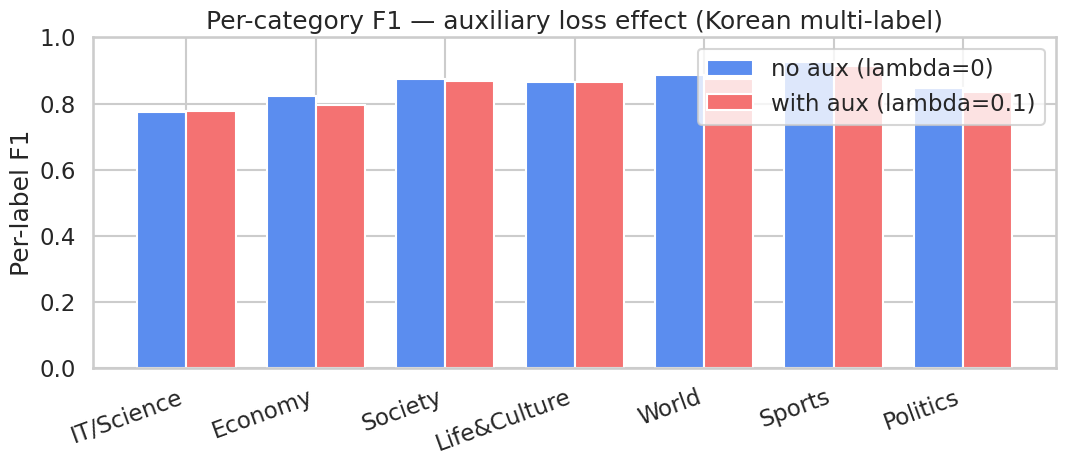

In [22]:
def per_label_f1(Y_true, Y_pred):
    f1s = []
    for k in range(K):
        _, _, f1, _ = precision_recall_fscore_support(
            Y_true[:, k], Y_pred[:, k], average="binary", zero_division=0,
        )
        f1s.append(float(f1))
    return f1s


f1_no_aux = per_label_f1(labels_eval, preds_main_no_aux)
f1_aux    = per_label_f1(labels_eval, preds_main_aux)

label_cmp = pd.DataFrame({
    "category":              LABEL_NAMES_EN,
    "no aux F1":             f1_no_aux,
    "with aux F1":           f1_aux,
    "delta (aux - no_aux)":  np.array(f1_aux) - np.array(f1_no_aux),
})
print(label_cmp.round(4).to_string(index=False))

# 막대 그래프
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(K)
width = 0.38
ax.bar(x_pos - width/2, f1_no_aux, width, label="no aux (lambda=0)",    color="#5B8DEF")
ax.bar(x_pos + width/2, f1_aux,    width, label="with aux (lambda=0.1)", color="#F47272")
ax.set_xticks(x_pos)
ax.set_xticklabels(LABEL_NAMES_EN, rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Per-label F1")
ax.set_title("Per-category F1 — auxiliary loss effect (Korean multi-label)")
ax.legend()
plt.tight_layout()
plt.show()

**해석**

- **활성률 높은 카테고리** (스포츠/세계/사회 등): baseline 자체 F1 이 높음. delta 는 작거나 0 — 이미 신호가 충분.
- **활성률 낮은·헷갈리는 카테고리** (정치/IT과학 등): baseline F1 이 낮음. 보조 신호의 *정규화 효과* 가 상대적으로 도움이 될 가능성 — 그래도 5K 샘플·2 epoch quick 모드에선 delta 가 노이즈 영역 (±0.01) 안에 머무를 수 있음.
- **모든 카테고리 delta 가 ±0.005 이내** → quick 모드 표본의 노이즈 영역. 학습량 (epoch·데이터) 을 늘려야 보조 효과가 통계적으로 분리 가능.

### 8-3. 보조 task 자체는 얼마나 잘 학습됐나

`n_active` 는 1 또는 2 정수만 나오므로 *binary 같은 회귀* 입니다. RMSE 가 0 에 가까우면 모델이 두 경우를 잘 구분, 0.5 근처면 무작위 추측 (분산이 0.25 인 1-vs-2 분포).

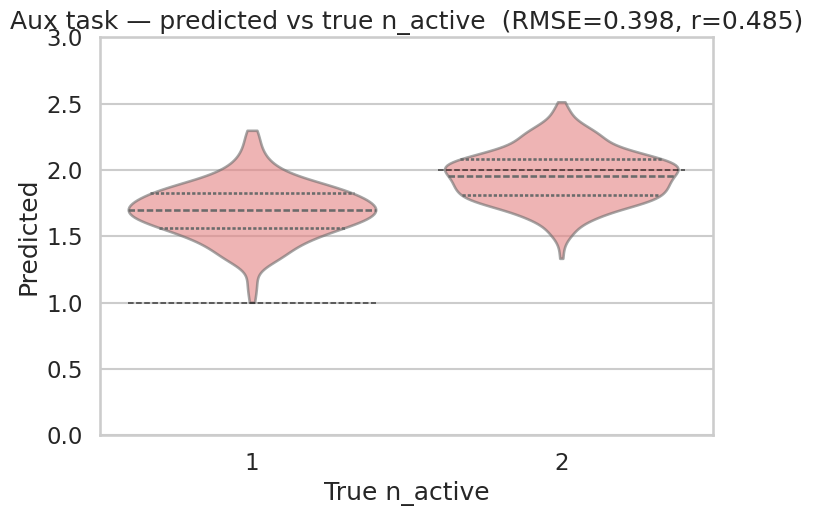

In [23]:
# True n_active 별 예측 분포 — violin
df_aux = pd.DataFrame({
    "True n_active": [f"{int(v)}" for v in aux_true],
    "Predicted":     aux_preds_aux,
})
order = ["1", "2"]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.violinplot(
    data=df_aux, x="True n_active", y="Predicted",
    order=order, inner="quart", cut=0,
    color="#F47272", alpha=0.6, ax=ax,
)
# 정답 위치 점선 가이드
for i, target in enumerate([1.0, 2.0]):
    ax.hlines(target, i - 0.4, i + 0.4, color="black", lw=1.1, ls="--", alpha=0.7)
ax.set_ylim(0.0, 3.0)
ax.set_title(f"Aux task — predicted vs true n_active  (RMSE={rmse_aux:.3f}, r={pear_aux:.3f})")
plt.tight_layout()
plt.show()

**해석**

- 두 violin (n_active=1, n_active=2) 의 *중심* 이 점선 가이드 (1.0 / 2.0) 에 잘 맞으면 보조 헤드가 활성 개수를 잘 학습한 것.
- *분포 폭* — 모델이 두 경우를 *자신 있게* 구분하면 violin 이 좁고 점선 가이드에 집중. 폭이 넓고 두 violin 이 0.5 근처에서 겹치면 학습 부족.
- 1.5 근처에 한 데가 몰려 있으면 *상수 평균 예측* 으로 회귀 — 보조 신호가 메인 표상에 *반영되지 못한* 상태. 이 경우 λ 를 더 키우거나 데이터·epoch 를 늘려야 함.

## 9. 🛠️ 변형 — λ 스윕 효과 비교 (선택)

§8 은 λ=0 vs λ=0.1 두 점만 비교했습니다. λ 를 *그리드* 로 돌리면 *어떤 λ 가 메인 task 에 가장 도움이 되는지* 알 수 있습니다 — 운영 시 실제 grid search 패턴.

이 셀은 학습 시간이 약 10분씩 늘어 *선택 사항* — 시간 여유 있을 때만 실행. (또는 λ 한두 점만 추가해서 빠르게.)

In [24]:
# 시간 여유 있을 때만 실행 — 각 lambda 마다 처음부터 다시 학습
LAMBDA_GRID = [0.0, 0.1, 1.0]   # 빠르게 보고 싶으면 [0.0, 0.1] 만
RUN_LAMBDA_SWEEP = False        # ← True 로 바꿔 실행

sweep_results = []

if RUN_LAMBDA_SWEEP:
    for lam in LAMBDA_GRID:
        print(f"\n{'='*60}")
        print(f"Training with lambda_aux = {lam}")
        print(f"{'='*60}")
        m = make_model()
        args = TrainingArguments(
            output_dir=f"./ch18_sweep_lam{lam}",
            num_train_epochs=2,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            fp16=True,
            eval_strategy="no",
            logging_steps=200,
            save_strategy="no",
            report_to="none",
            seed=SEED,
            remove_unused_columns=False,
        )
        tr = AuxTrainer(
            model=m, args=args,
            train_dataset=train_tok, eval_dataset=eval_tok,
            data_collator=collator, processing_class=tokenizer,
            compute_metrics=compute_metrics_main, lambda_aux=lam,
        )
        tr.train()
        ev = tr.evaluate()
        sweep_results.append({
            "lambda": lam,
            "macro_f1": float(ev.get("eval_macro_f1", float("nan"))),
            "micro_f1": float(ev.get("eval_micro_f1", float("nan"))),
            "macro_auc": float(ev.get("eval_macro_auc", float("nan"))),
        })
        del m, tr
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    sweep_df = pd.DataFrame(sweep_results)
    print("\nLambda sweep result:")
    print(sweep_df.round(4).to_string(index=False))
else:
    print("Lambda sweep skipped. Set RUN_LAMBDA_SWEEP=True to run (~30 min extra on T4).")

Lambda sweep skipped. Set RUN_LAMBDA_SWEEP=True to run (~30 min extra on T4).


**해석 가이드 — 결과를 직접 보면**

- macro_f1 이 λ=0.1 에서 최대 → 가벼운 보조 가중치가 정규화 효과로 메인 도움.
- macro_f1 이 λ=1.0 에서 최대 → 보조 신호가 충분히 강해 둘 다 학습.
- macro_f1 이 λ=0 에서 최대 (baseline 이 가장 좋음) → 보조 task 가 이 셋업에선 도움 안 됨. quick 모드 노이즈일 수 있어 시드 바꿔 재실행 권장.

## 10. 🧭 결과 해석 — 보조 loss 가 *항상 좋게 나오지는 않습니다*

Ch 14 에서 짚었던 4 가지 시나리오를 한국어 셋업에서도 그대로 적용:

| delta 패턴 | 의미 | 권장 다음 단계 |
|---|---|---|
| **모든 카테고리 +1-3%p** | 정규화 효과 고르게 작동 (이상적) | λ 를 0.03·0.1·0.3 으로 grid search |
| **일부 카테고리만 향상, 나머지 0 또는 음수** ← *quick 모드 전형* | 학습량 부족 카테고리가 둘 다 baseline 근처에 머묾 | 데이터·에폭 늘리기가 우선 |
| **모든 카테고리 거의 0 변화** | 보조 신호가 메인 표상에 추가 정보를 못 줌 (n_active 가 너무 *예측하기 쉬워* 학습 신호로서 약함) | 보조 task 자체를 바꿔야 함 — 예: 헤드라인 길이 회귀, 발행일자 회귀 |
| **모든 카테고리 음수** | 보조가 메인 학습을 방해 | λ 줄이거나 보조 task 제거 |

### Ch 18 특유의 *주의점* — `n_active` 는 *너무 예측하기 쉬워* 신호로서 약할 수 있음

`n_active` 는 합성 규칙상 1/7 확률로 1, 6/7 확률로 2. *상수 1.857* 만 예측해도 MSE 가 0.12 정도로 낮습니다. 모델이 *진짜 입력을 보지 않고* 평균만 출력해도 보조 loss 가 작게 유지되어 *보조 신호가 학습으로 흐르지 않는* 상황이 가능합니다.

진단:
- 보조 RMSE 가 0.34 (상수 평균 베이스라인) 와 *비슷* → 보조가 평균만 학습한 상태. 메인에 도움 안 됨.
- 보조 RMSE 가 0.34 보다 *유의미하게 작음* (e.g. 0.20) → 보조가 입력을 실제로 활용. 메인 정규화 효과 기대 가능.
- 보조 Pearson r 이 0.3 이상 → 입력 의존적 학습이 일어남.

> *이 챕터의 메시지* — auxiliary loss 는 *공짜 만병통치약* 이 아닙니다. *어떤 보조 task 를 쓰는가* 가 성패를 결정. `n_active` 는 *데이터 합성 자연 부산물* 이라 손쉽게 시도해 볼 가치는 있지만, 진짜 도움이 되려면 *입력 의존도 가 큰* 보조 (예: 헤드라인 분야 외 추가 메타데이터) 가 더 효과적. Ch 14 의 별점은 *사용자가 직접 입력한 깨끗한 신호* 라 입력 의존도가 높았던 셋업.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `AutoModel.from_pretrained(...)` | 분류 헤드 없이 BERT 본체만 로드 — 메인·보조 헤드를 직접 부착 | Phase 3 토크나이저 학습엔 등장 안 함 (Ch 19 부터는 본체보다 어휘 자체에 집중) |
| 커스텀 `nn.Module` (KoBertMultiTask) | 본체 공유 + 두 헤드 명시 정의 — multi-task 정통 패턴 | GPT 챕터 (Ch 21) 의 task-specific head 패턴과 연결 |
| `Trainer.compute_loss` 오버라이드 + `lambda_aux` 인자 | 자동 매핑이 못 다루는 *복합 loss* + λ 동적 주입 | λ grid search 패턴 |
| 커스텀 `AuxCollator` | input_ids 외 *추가 라벨* (n_active) 도 batch 에 같이 담기 | Ch 14 와 같은 패턴, 보조 신호 변형마다 재사용 |
| `remove_unused_columns=False` | 모델 시그니처와 무관하게 모든 컬럼 통과 | custom collator 패턴마다 |
| `SequenceClassifierOutput` | Trainer 호환 출력 형식 (loss + logits) — 커스텀 모델에서도 표준 dict 반환 | 커스텀 모델 패턴마다 |
| `r2_score`, `np.corrcoef` | 회귀 보조 metric (R², Pearson r) | 회귀 결합 task 마다 |

## 🎯 체크포인트 질문

1. Ch 14 (영어 별점 보조) 와 Ch 18 (한국어 활성 개수 보조) 의 *변경된 축* 은 무엇인가요? *한 가지 축* 원칙 관점에서 어느 쪽이 더 "loss 축 변화" 에 가까운가요?
2. `n_active` 가 메인 multi-hot 벡터의 *합* 이라는 점이 보조 task 로서 *유리한 점* 과 *불리한 점* 을 각각 한 줄로.
3. `AutoModelForSequenceClassification` 대신 `AutoModel + 커스텀 nn.Module` 로 간 이유는? 어떤 상황에서 자동 매핑이 부족한가요?
4. λ=0.1 을 기본값으로 잡은 근거는? (메인 BCE 와 보조 MSE 의 *크기 자체* 가 어떻게 다른가)

## ❓ FAQ

### Q1. (실무) `n_active` 외에 어떤 보조 task 를 시도할 수 있나요?

KLUE-YNAT 합성 데이터에서 *공짜로* 얻을 수 있는 보조 신호:

| 보조 task | 라벨 형식 | 예상 효과 |
|---|---|---|
| 헤드라인 길이 (토큰 수) | float (정규화) | 약함 — 길이는 카테고리와 상관 약함 |
| 두 원본 헤드라인의 *주제 유사도* | float [0, 1] | 중간 — 유사 주제 결합 vs 이질 결합 구분 |
| 두 카테고리의 *id 차이* `abs(c_A - c_B)` | int | 약함 — id 자체가 의미 없음 |
| **원본 단일 카테고리 예측** (combined 가 아닌 *각 절반* 의 카테고리) | int | 강함 — 메인과 직접 관련, 추천 |

원본 카테고리 예측을 보조로 쓰려면 `make_multilabel` 에서 `(c_A, c_B)` 를 *순서 라벨* 로 보존하고 보조 헤드를 `Linear(H, K) × 2` 로 두 개 만들면 됩니다 (multi-task 가 *3-task* 가 됨 — multi-label + 2개 single-label).

### Q2. (이론) `n_active` 가 메인의 *합* 이라는 게 왜 *보조로 쓰면 의외로 약한* 신호인가요?

직관적으로는 "메인을 잘 풀면 합도 잘 풂" 인데, 역방향 ("합을 잘 풀면 메인도 잘 풂") 의 정보량이 작기 때문입니다.

- 메인이 잘 풀린 모델 → `n_active` 도 잘 추정 (정의상 합이니까).
- 그러나 *보조만 잘 학습* 된 모델 → "이 헤드라인이 1개 vs 2개 카테고리에 걸친다" 만 알지 *어느* 카테고리인지의 정보는 없음. 표현 공간이 카테고리 *식별* 방향이 아니라 *개수* 방향으로 발전.
- BCE per-label 의 gradient 가 *어느* 카테고리를 활성할지 직접 학습 신호. MSE on n_active 의 gradient 는 *몇 개* 인지만 학습 신호.

따라서 `n_active` 가 메인의 *함수* 이긴 하지만 *전사 가능한 inverse 가 없는 함수* 라 보조로서의 추가 정보량이 제한적. Ch 14 의 별점은 항목 분류와 *부분* 상관이지만 *완전히 다른 방향* 의 정보 (감성) 라 BERT 표상에 *추가* 차원을 만듭니다 — 그래서 보조 효과 자체는 별점 쪽이 클 가능성.

### Q3. (실무) `AutoModel + nn.Module` 패턴이 `model.aux_head = nn.Linear(...)` 한 줄 부착보다 권장되는 경우는?

| 상황 | 권장 패턴 |
|---|---|
| 보조 헤드 1개, 메인은 표준 분류 | 한 줄 부착 (Ch 14 패턴) — 간결 |
| 보조 헤드 2개+, 또는 메인 헤드도 비표준 | `nn.Module` 정의 (Ch 18 패턴) — 명시성 |
| layer-wise lr 차등 (BERT 본체는 작은 lr, 헤드는 큰 lr) | `nn.Module` — `named_parameters` 로 그룹 분리 쉬움 |
| 헤드별 dropout 등 미세 조정 | `nn.Module` — `__init__` 에서 한 곳에 정의 |
| BERT 본체 일부 layer freeze | 둘 다 가능, 명시 정의가 가독성 더 좋음 |

```python
# nn.Module 패턴이면 named_parameters 분리가 깔끔
optimizer_grouped = [
    {"params": [p for n, p in model.named_parameters() if n.startswith("bert.")],   "lr": 2e-5},
    {"params": [p for n, p in model.named_parameters() if n.startswith("cls_head")],"lr": 1e-4},
    {"params": [p for n, p in model.named_parameters() if n.startswith("count_head")],"lr": 1e-4},
]
optimizer = torch.optim.AdamW(optimizer_grouped)
```

### Q4. (이론) 보조 loss 가 *MSE* 대신 *MAE (L1)* 면 학습 양상이 어떻게 달라지나요?

`n_active` 는 1 또는 2 정수라 분포가 *binary 같음*. MAE 와 MSE 의 차이:

- **MSE**: gradient 가 잔차에 *비례* — 큰 오차에 큰 gradient. 평균값 ($\sim$ 1.86) 으로 수렴.
- **MAE (L1)**: gradient 가 잔차의 *부호* 만 (크기 일정 ±1). 중앙값 (= 2, 빈도 6/7) 으로 수렴.

따라서 MAE 로 바꾸면 보조 헤드가 *항상 2 를 예측* 하게 되어 (중앙값 = 2) 학습 신호가 거의 없습니다. binary-같은 회귀에선 MSE 가 더 적절.

또 다른 선택: `n_active - 1` 을 *binary 분류* 로 풀어 `BCEWithLogitsLoss` 적용 — 1 vs 2 를 0 vs 1 로 매핑. 회귀보다 분류가 더 자연스러운 형식이지만, *연속적 보조 신호* 라는 multi-task 의 전통적 셋업에선 회귀가 일반적.

```python
# 보조를 binary 분류로 — n_active in {1, 2} → {0, 1}
aux_logits = self.count_head(cls).squeeze(-1)   # (B,)
aux_target = (n_active - 1).float()             # 1→0, 2→1
l_aux = F.binary_cross_entropy_with_logits(aux_logits, aux_target)
```

### Q5. (실무) 학습 중 보조 loss 가 *증가* 하면 어떻게 진단하나요?

`logging_steps=50` 으로 학습 곡선 (train loss) 만 보면 *combined loss 만* 출력됩니다. 보조 loss 만 분리해 추적하려면 `compute_loss` 안에서 직접 log:

```python
def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
    inputs = {**inputs, "lambda_aux": self.lambda_aux}
    outputs = model(**inputs)
    loss = outputs.loss
    # 학습 중 보조 loss 따로 로깅 (커스텀 추가)
    if self.state.global_step % 50 == 0 and not return_outputs:
        # 모델 forward 안에서 self.last_count_pred 가 저장됨 — 따로 다시 계산
        with torch.no_grad():
            cls = model.bert(**{k: v for k, v in inputs.items()
                                if k in ("input_ids", "attention_mask", "token_type_ids")}
                            ).last_hidden_state[:, 0, :]
            count_pred = model.count_head(cls).squeeze(-1)
            l_aux_only = F.mse_loss(count_pred, inputs["n_active"].float()).item()
        print(f"step {self.state.global_step}  main+aux={loss.item():.4f}  aux_only={l_aux_only:.4f}")
    return (loss, outputs) if return_outputs else loss
```

보조 loss 가 *상승* 한다면:
- λ 가 너무 작아 보조 학습이 *메인 방향에 휘둘림* — λ 키워 보조 학습 강화.
- 또는 메인과 보조가 *충돌 방향* — λ 줄이거나 보조 제거.

### Q6. (이론) Ch 14 와 Ch 18 의 결과 (delta) 패턴이 *다를* 거라 예상되는 이유는?

| 측면 | Ch 14 (영어, 별점) | Ch 18 (한국어, n_active) |
|---|---|---|
| 보조 신호의 *입력 의존도* | 높음 — 사용자가 *직접* 매긴 감성 평가 | 낮음 — 합성 규칙의 기계적 함수 (1/7 확률) |
| 보조 신호의 *메인과의 독립 차원* | 다른 차원 (감성 vs 항목) | 같은 차원의 함수 (합) |
| 보조 정답의 분포 | 1-5 별점 (5 카테고리) | 1 또는 2 (이항 같음) |
| 보조 정답 예측 난이도 | 중간 — 진짜 회귀 | 매우 쉬움 — 상수 평균만 예측해도 RMSE 작음 |
| 예상 메인 delta | 약 양수 (별점 신호가 항목 표상 보강) | 약 0 (n_active 신호가 추가 정보 적음) |

따라서 quick 모드에선 Ch 18 delta 가 *더 작게* 나올 가능성. 그래도 셋업 자체는 *멀티태스크 학습의 정통 패턴* 을 한국어 환경에서 검증하는 가치가 있고, FAQ Q1 처럼 *더 유용한 보조 task* 로 확장하는 출발점.

### Q7. (실무) Phase 2 (한국어, Ch 15-18) 가 끝났습니다. Phase 3 에서 토크나이저를 *직접 학습* 하는 이유는?

Ch 1-18 모두 *사전학습 토크나이저* (sklearn TF-IDF 토큰화, BERT WordPiece) 에 의존했습니다. Phase 3 (Ch 19-20) 는 이 의존을 끊고 *어휘 자체를 코퍼스에서 학습*:

- **Ch 19**: BPE / WordPiece / Unigram 알고리즘을 직접 돌려 어휘 만들기 → 토큰화가 *데이터에 따라 어떻게 달라지는지* 직관.
- **Ch 20**: 학습한 토크나이저로 *작은 BERT 를 처음부터* 사전학습 → 사전학습 의존 없는 경험.

> Phase 3 가 클라이맥스인 이유 — Ch 1 부터 따라온 "🔤 토크나이저 노트" 가 *외부 도구의 사용법* 이었다면 Phase 3 는 *그 도구 자체를 만드는 단계*. 토크나이저를 직접 만들고 나면 Ch 1-18 의 모든 토큰화 노트를 *다시 읽었을 때* 보이는 풍경이 달라집니다.

## 🚀 삽질 코너 (선택)

다음 두 가지 흔한 함정:

**1. `remove_unused_columns=True` (기본값) 로 두기**

```python
training_args = TrainingArguments(
    ...,
    remove_unused_columns=True,   # ← 잘못 (default)
)
```

Trainer 가 model.forward 시그니처를 검사해 *맞지 않는 컬럼은 제거*. `n_active` 가 시그니처에 있긴 하지만 자동 검사가 실패할 때 (e.g. 커스텀 모델 시그니처 변경 시) `n_active` 가 사라져 `compute_loss` 안에서 None 이 됩니다. 안전상 `False` 권장.

**2. `count_pred` 를 모델 attribute 에 저장 안 하기**

```python
# KoBertMultiTask.forward 안에서
return SequenceClassifierOutput(loss=loss, logits=main_logits)
# count_pred 를 어디에도 저장 안 함 → eval 단계에서 보조 metric 측정 불가
```

`SequenceClassifierOutput` 은 `loss`/`logits`/`hidden_states`/`attentions` 만 표준 필드. `count_pred` 를 추가하려면 dataclass 를 직접 정의하거나, 본문처럼 `self.last_count_pred = ...` 에 저장해 eval 단계에서 꺼냅니다. 후자가 간단하지만 *멀티 GPU 학습 시 race condition* 가능 — 운영 코드는 정식 dataclass 정의 권장.

## 다음 챕터 예고 — Phase 3 시작 (클라이맥스)

**Chapter 19. 토크나이저 직접 학습 — BPE / WordPiece / Unigram**

- Phase 1-2 영어·한국어 모두 *사전학습 토크나이저* 를 그대로 썼습니다. Ch 19 는 그 의존을 끊고 *어휘를 코퍼스에서 직접 학습*.
- `tokenizers` 라이브러리로 BPE, WordPiece, Unigram 세 알고리즘을 같은 코퍼스에 적용해 *어휘 차이* 비교.
- 한국어 vs 영어 코퍼스에서 학습한 토크나이저의 *토큰 길이 분포* 가 어떻게 다른지 — Ch 1 부터 추적해 온 토크나이저 시각의 완성.

> **Phase 2 마무리** — Ch 15-18 을 통해 한국어 BERT 의 binary·multi-class·multi-label·auxiliary 4 가지를 다 익혔습니다. Phase 3 는 한 발 더 내려가 *어휘 구성* 자체에 도전 — 사전학습 모델에 *완전히 의존하지 않는* 경험.

> **변하는 축**: 모델·loss·task 가 아니라 *토크나이저 그 자체* 가 학습 대상. 입력 표현이 만들어지는 *가장 아래 단계* 로 내려갑니다.